# HDBSCAN Parameter Persistence Analysis

Compute cluster persistence scores across parameter choices to identify robust structures.

**Configuration:** Set `DATASET` in the first code cell to analyze either:
- `"posterior"` - Manticore-Local posterior clusters (Mode 1 output)
- `"control"` - Random control clusters (Mode 3 output)

In [1]:
import numpy as np
import h5py
import re
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

OUTPUT_DIR = Path("../output")
OVERLAP_THRESHOLD = 0.5  # Minimum Jaccard overlap to consider clusters "the same"

# =============================================================================
# CONFIGURATION: Choose which dataset to analyze
# =============================================================================
# Set to "posterior" for Manticore-Local posterior clusters (Mode 1 output)
# Set to "control" for random control clusters (Mode 3 output)
DATASET = "control"  # Options: "posterior" or "control"

# File patterns for each dataset type
FILE_PATTERNS = {
    "posterior": "hdbscan_clusters_mcs_*_ms_*.h5",
    "control": "random_control_clusters_mcs_*_ms_*.h5"
}

# Output filename prefixes
OUTPUT_PREFIXES = {
    "posterior": "hdbscan_clusters",
    "control": "random_control_clusters"
}

print(f"Dataset: {DATASET}")
print(f"File pattern: {FILE_PATTERNS[DATASET]}")

Dataset: control
File pattern: random_control_clusters_mcs_*_ms_*.h5


## Load All Parameter Runs

In [2]:
def parse_filename(filename):
    """Extract (min_cluster_size, min_samples) from filename."""
    match = re.search(r'mcs_(\d+)_ms_(\d+)', filename)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

def load_cluster_members(filepath):
    """Load cluster member indices from HDF5 file.
    
    Uses the global halo index from /assignments as the unique identifier.
    This is stable across runs since all use the same input data.
    """
    clusters = {}
    with h5py.File(filepath, 'r') as f:
        if 'assignments' not in f or 'label' not in f['assignments']:
            print(f"Warning: No assignments found in {filepath}")
            return clusters
        
        labels = f['assignments/label'][:]
        
        cluster_attrs = {}
        if 'clusters' in f:
            for cluster_name in f['clusters'].keys():
                cid = int(cluster_name.split('_')[1])
                grp = f[f'clusters/{cluster_name}']
                cluster_attrs[cid] = {
                    'existence_prob': grp.attrs.get('existence_prob', np.nan),
                    'center_xyz': grp.attrs.get('center_xyz', np.array([np.nan]*3)),
                    'mean_m200_mass': grp.attrs.get('mean_m200_mass', np.nan)
                }
        
        unique_labels = np.unique(labels)
        for label in unique_labels:
            if label == -1:
                continue
            member_indices = set(np.where(labels == label)[0])
            attrs = cluster_attrs.get(label, {})
            clusters[label] = {
                'members': member_indices,
                'n_members': len(member_indices),
                'existence_prob': attrs.get('existence_prob', np.nan),
                'center_xyz': attrs.get('center_xyz', np.array([np.nan]*3)),
                'mean_m200_mass': attrs.get('mean_m200_mass', np.nan)
            }
    return clusters

# Find all HDBSCAN output files using the configured pattern
file_pattern = FILE_PATTERNS[DATASET]
files = sorted(OUTPUT_DIR.glob(file_pattern))
print(f"Found {len(files)} parameter runs for dataset '{DATASET}'")

if len(files) == 0:
    raise FileNotFoundError(f"No files matching '{file_pattern}' found in {OUTPUT_DIR}")

# Load all runs
all_runs = {}
for f in files:
    mcs, ms = parse_filename(f.name)
    if mcs is not None:
        all_runs[(mcs, ms)] = load_cluster_members(f)

# Filter out degenerate runs (phase transition regime)
MIN_CLUSTERS = 100  # Runs with fewer clusters are likely degenerate
max_clusters = max(len(c) for c in all_runs.values())

runs = {}
excluded = []
for params, clusters in all_runs.items():
    n_clusters = len(clusters)
    if n_clusters >= MIN_CLUSTERS:
        runs[params] = clusters
    else:
        excluded.append((params, n_clusters))

print(f"\nFiltering runs with < {MIN_CLUSTERS} clusters:")
print(f"  Kept: {len(runs)} runs")
print(f"  Excluded: {len(excluded)} degenerate runs")
if excluded:
    print(f"  Excluded params: {[(p, n) for p, n in sorted(excluded)]}")

print(f"\nCluster counts in valid runs:")
for params in sorted(runs.keys()):
    print(f"  mcs={params[0]}, ms={params[1]}: {len(runs[params])} clusters")

if len(runs) < 2:
    raise ValueError("Need at least 2 valid parameter runs for persistence analysis")

Found 256 parameter runs for dataset 'control'

Filtering runs with < 100 clusters:
  Kept: 132 runs
  Excluded: 124 degenerate runs
  Excluded params: [((10, 5), 5), ((10, 7), 2), ((10, 12), 2), ((10, 13), 2), ((10, 16), 4), ((10, 17), 4), ((11, 5), 5), ((11, 13), 2), ((11, 16), 3), ((11, 17), 4), ((12, 5), 4), ((12, 13), 2), ((12, 14), 2), ((12, 16), 3), ((12, 17), 4), ((13, 5), 3), ((13, 6), 4), ((13, 13), 2), ((13, 14), 2), ((13, 16), 3), ((13, 17), 4), ((14, 5), 3), ((14, 6), 4), ((14, 12), 3), ((14, 13), 2), ((14, 14), 2), ((14, 16), 3), ((14, 17), 4), ((14, 18), 3), ((15, 5), 3), ((15, 6), 2), ((15, 12), 2), ((15, 13), 2), ((15, 14), 2), ((15, 16), 3), ((15, 17), 4), ((15, 18), 3), ((16, 5), 2), ((16, 12), 2), ((16, 14), 2), ((16, 15), 2), ((16, 16), 3), ((16, 17), 4), ((16, 18), 3), ((17, 11), 2), ((17, 12), 2), ((17, 14), 2), ((17, 15), 2), ((17, 16), 3), ((17, 17), 4), ((17, 18), 3), ((17, 19), 9), ((17, 20), 3), ((18, 11), 2), ((18, 12), 2), ((18, 14), 2), ((18, 15), 2), ((1

## Match Clusters Across Runs

In [3]:
# FAST approach: inverted index to avoid unnecessary comparisons
# Key insight: two clusters can only match if they share at least one halo

def build_inverted_index(runs):
    """Build inverted index: halo_id -> list of (params, cluster_id)."""
    index = defaultdict(list)
    cluster_members = {}  # (params, cid) -> set of members
    cluster_sizes = {}    # (params, cid) -> size
    
    for params, clusters in runs.items():
        for cid, cdata in clusters.items():
            members = cdata['members']
            key = (params, cid)
            cluster_members[key] = members
            cluster_sizes[key] = len(members)
            for halo_id in members:
                index[halo_id].append(key)
    
    return index, cluster_members, cluster_sizes

def find_candidates(params, cid, members, inverted_index):
    """Find clusters in OTHER runs that share at least one halo."""
    candidates = defaultdict(set)  # other_params -> set of candidate cids
    for halo_id in members:
        for (other_params, other_cid) in inverted_index[halo_id]:
            if other_params != params:
                candidates[other_params].add(other_cid)
    return candidates

def jaccard_sets(set_a, set_b):
    """Compute Jaccard similarity between two sets."""
    intersection = len(set_a & set_b)
    union = len(set_a) + len(set_b) - intersection
    return intersection / union if union > 0 else 0.0

def precompute_all_matches_fast(runs, threshold=OVERLAP_THRESHOLD):
    """Precompute matches using inverted index (much faster)."""
    print("Building inverted index...")
    inverted_index, cluster_members, cluster_sizes = build_inverted_index(runs)
    print(f"  Index size: {len(inverted_index)} unique halos")
    
    matches = {}  # (from_params, to_params) -> {from_cid: (to_cid, jaccard) or None}
    param_list = list(runs.keys())
    
    # Initialize match dictionaries
    for p1 in param_list:
        for p2 in param_list:
            if p1 != p2:
                matches[(p1, p2)] = {}
    
    # Process each run
    total_clusters = sum(len(c) for c in runs.values())
    
    with tqdm(total=total_clusters, desc="Computing matches") as pbar:
        for params, clusters in runs.items():
            for cid, cdata in clusters.items():
                members = cdata['members']
                size_a = len(members)
                
                # Find candidate clusters in other runs
                candidates = find_candidates(params, cid, members, inverted_index)
                
                # For each other run, find best match among candidates
                for other_params in param_list:
                    if other_params == params:
                        continue
                    
                    best_jaccard = 0
                    best_match = None
                    
                    for other_cid in candidates.get(other_params, []):
                        other_members = cluster_members[(other_params, other_cid)]
                        size_b = len(other_members)
                        
                        # Size filter
                        if size_a > 2 * size_b or size_b > 2 * size_a:
                            continue
                        
                        jaccard = jaccard_sets(members, other_members)
                        if jaccard > best_jaccard:
                            best_jaccard = jaccard
                            best_match = other_cid
                    
                    if best_jaccard >= threshold:
                        matches[(params, other_params)][cid] = (best_match, best_jaccard)
                    else:
                        matches[(params, other_params)][cid] = None
                
                pbar.update(1)
    
    return matches

def compute_persistence_from_matches(params, cluster_ids, matches, param_list):
    """Fast persistence lookup using precomputed matches."""
    persistence = {}
    n_runs = len(param_list)
    
    for cid in cluster_ids:
        appearances = 1  # counts itself
        for other_params in param_list:
            if other_params == params:
                continue
            match_result = matches[(params, other_params)].get(cid)
            if match_result is not None:
                appearances += 1
        persistence[cid] = appearances / n_runs
    
    return persistence

# Precompute everything
param_list = list(runs.keys())
print(f"Precomputing matches across {len(param_list)} runs...")
all_matches = precompute_all_matches_fast(runs)
print("\nDone! All subsequent lookups are instant.")

Precomputing matches across 132 runs...
Building inverted index...
  Index size: 234147 unique halos


Computing matches:   0%|          | 0/392068 [00:00<?, ?it/s]


Done! All subsequent lookups are instant.


## Optimal Parameter Recommendation

In [4]:
# For each parameter setting, compute persistence for its own clusters (instant!)
param_scores = {}

for params in tqdm(param_list, desc="Evaluating parameter sets"):
    run_clusters = runs[params]
    persistence = compute_persistence_from_matches(params, run_clusters.keys(), all_matches, param_list)
    
    n_robust = sum(1 for p in persistence.values() if p >= 0.7)
    
    param_scores[params] = {
        'n_clusters': len(run_clusters),
        'n_robust': n_robust,
        'robust_fraction': n_robust / len(run_clusters) if len(run_clusters) > 0 else 0
    }

print(f"\nParameter Comparison ({DATASET} dataset):")
print("=" * 70)
print(f"{'mcs':>5} {'ms':>5} {'clusters':>10} {'robust':>10} {'robust_frac':>12}")
print("-" * 70)

for params in sorted(param_scores.keys()):
    s = param_scores[params]
    print(f"{params[0]:>5} {params[1]:>5} {s['n_clusters']:>10} {s['n_robust']:>10} {s['robust_fraction']:>12.1%}")

# Recommend: highest n_robust (absolute count)
best_params = max(param_scores.keys(), 
                  key=lambda p: param_scores[p]['n_robust'])

print(f"\n** RECOMMENDED for {DATASET}: mcs={best_params[0]}, ms={best_params[1]} **")
print(f"   {param_scores[best_params]['n_clusters']} clusters, "
      f"{param_scores[best_params]['n_robust']} robust, "
      f"{param_scores[best_params]['robust_fraction']:.1%} robust fraction")

Evaluating parameter sets:   0%|          | 0/132 [00:00<?, ?it/s]


Parameter Comparison (control dataset):
  mcs    ms   clusters     robust  robust_frac
----------------------------------------------------------------------
   10     6       6941         94         1.4%
   10     8       5359        166         3.1%
   10     9       4867        174         3.6%
   10    10       4384        194         4.4%
   10    11       4063        169         4.2%
   10    14       3196        103         3.2%
   10    15       2980         93         3.1%
   10    18       2453         59         2.4%
   10    19       2401         49         2.0%
   10    20       2204         36         1.6%
   11     6       6277         95         1.5%
   11     7       5496        131         2.4%
   11     8       4911        167         3.4%
   11     9       4466        179         4.0%
   11    10       4038        194         4.8%
   11    11       3717        164         4.4%
   11    12       3479        151         4.3%
   11    14       2914        109         

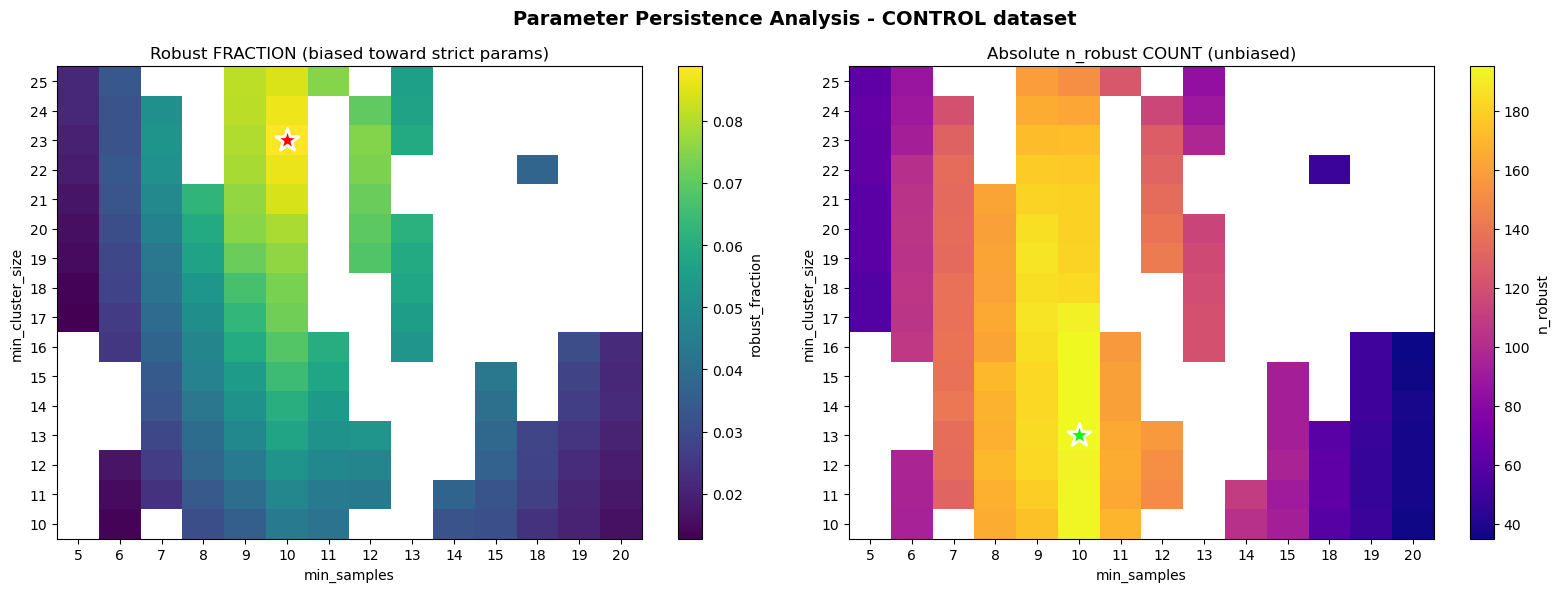


Dataset: control
Best by fraction: mcs=23, ms=10 -> n_robust=173, n_clusters=1949
Best by absolute: mcs=13, ms=10 -> n_robust=195, n_clusters=3416


In [5]:
# 2D heatmaps: robust_fraction vs n_robust (absolute)
mcs_values = sorted(set(p[0] for p in param_scores.keys()))
ms_values = sorted(set(p[1] for p in param_scores.keys()))

# Build 2D grids
robust_frac_grid = np.full((len(mcs_values), len(ms_values)), np.nan)
n_robust_grid = np.full((len(mcs_values), len(ms_values)), np.nan)
n_clusters_grid = np.full((len(mcs_values), len(ms_values)), np.nan)

for (mcs, ms), scores in param_scores.items():
    i = mcs_values.index(mcs)
    j = ms_values.index(ms)
    robust_frac_grid[i, j] = scores['robust_fraction']
    n_robust_grid[i, j] = scores['n_robust']
    n_clusters_grid[i, j] = scores['n_clusters']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Parameter Persistence Analysis - {DATASET.upper()} dataset", fontsize=14, fontweight='bold')

# Left: robust_fraction (current metric - biased)
ax = axes[0]
im = ax.imshow(robust_frac_grid, cmap='viridis', aspect='auto', origin='lower')
ax.set_xticks(range(len(ms_values)))
ax.set_xticklabels(ms_values)
ax.set_yticks(range(len(mcs_values)))
ax.set_yticklabels(mcs_values)
ax.set_xlabel('min_samples')
ax.set_ylabel('min_cluster_size')
ax.set_title('Robust FRACTION (biased toward strict params)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('robust_fraction')

# Mark best by fraction
best_frac = max(param_scores.keys(), key=lambda p: param_scores[p]['robust_fraction'])
best_i = mcs_values.index(best_frac[0])
best_j = ms_values.index(best_frac[1])
ax.scatter(best_j, best_i, marker='*', s=300, c='red', edgecolors='white', linewidths=2)

# Right: n_robust (absolute count - what you actually want)
ax = axes[1]
im = ax.imshow(n_robust_grid, cmap='plasma', aspect='auto', origin='lower')
ax.set_xticks(range(len(ms_values)))
ax.set_xticklabels(ms_values)
ax.set_yticks(range(len(mcs_values)))
ax.set_yticklabels(mcs_values)
ax.set_xlabel('min_samples')
ax.set_ylabel('min_cluster_size')
ax.set_title('Absolute n_robust COUNT (unbiased)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('n_robust')

# Mark best by absolute count
best_abs = max(param_scores.keys(), key=lambda p: param_scores[p]['n_robust'])
best_i = mcs_values.index(best_abs[0])
best_j = ms_values.index(best_abs[1])
ax.scatter(best_j, best_i, marker='*', s=300, c='lime', edgecolors='white', linewidths=2)

plt.tight_layout()
plt.show()

print(f"\nDataset: {DATASET}")
print(f"Best by fraction: mcs={best_frac[0]}, ms={best_frac[1]} -> "
      f"n_robust={param_scores[best_frac]['n_robust']}, n_clusters={param_scores[best_frac]['n_clusters']}")
print(f"Best by absolute: mcs={best_abs[0]}, ms={best_abs[1]} -> "
      f"n_robust={param_scores[best_abs]['n_robust']}, n_clusters={param_scores[best_abs]['n_clusters']}")

## Export Persistence Scores for Final Catalog

In [ ]:
# Choose final parameters based on ABSOLUTE n_robust count (unbiased metric)
# The fraction metric is biased toward stricter params that find fewer clusters
best_by_absolute = max(param_scores.keys(), key=lambda p: param_scores[p]['n_robust'])
FINAL_PARAMS = best_by_absolute  # or set manually, e.g., (16, 12)
FINAL_PARAMS = (16, 13)

final_clusters = runs[FINAL_PARAMS]

print(f"Computing persistence for final {DATASET} catalog (instant lookup)...")
final_persistence = compute_persistence_from_matches(
    FINAL_PARAMS, final_clusters.keys(), all_matches, param_list
)

print(f"\nFinal {DATASET} catalog: mcs={FINAL_PARAMS[0]}, ms={FINAL_PARAMS[1]}")
print(f"Clusters with persistence scores: {len(final_persistence)}")

# Summary
persistence_vals = np.array(list(final_persistence.values()))
print(f"\nPersistence distribution:")
print(f"  Perfect (1.0): {np.sum(persistence_vals == 1.0)}")
print(f"  Robust (>=0.7): {np.sum(persistence_vals >= 0.7)}")
print(f"  Moderate (0.5-0.7): {np.sum((persistence_vals >= 0.5) & (persistence_vals < 0.7))}")
print(f"  Fragile (<0.5): {np.sum(persistence_vals < 0.5)}")

print(f"\nTop 10 most robust clusters:")
for cid in sorted(final_persistence.keys(), key=lambda x: -final_persistence[x])[:10]:
    cdata = final_clusters[cid]
    print(f"  Cluster {cid}: persistence={final_persistence[cid]:.2f}, "
          f"exist_prob={cdata['existence_prob']:.2f}, mass={cdata['mean_m200_mass']:.2e}")

In [ ]:
# Save persistence scores to the final HDF5 file
output_prefix = OUTPUT_PREFIXES[DATASET]
final_file = OUTPUT_DIR / f"{output_prefix}_mcs_{FINAL_PARAMS[0]}_ms_{FINAL_PARAMS[1]}.h5"

print(f"Saving to: {final_file}")

with h5py.File(final_file, 'r+') as f:
    # Add persistence scores to each cluster
    for cid, persistence in final_persistence.items():
        cluster_path = f'clusters/cluster_{cid}'
        if cluster_path in f:
            f[cluster_path].attrs['persistence_score'] = persistence
    
    # Add persistence metadata
    if 'persistence_analysis' in f:
        del f['persistence_analysis']
    pa = f.create_group('persistence_analysis')
    pa.attrs['n_parameter_runs'] = len(runs)
    pa.attrs['parameter_grid'] = str(list(runs.keys()))
    pa.attrs['overlap_threshold'] = OVERLAP_THRESHOLD
    pa.attrs['final_params'] = str(FINAL_PARAMS)
    pa.attrs['dataset_type'] = DATASET

print(f"Saved persistence scores to {final_file}")